In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile as tiff
from roifile import ImagejRoi
from skimage.draw import polygon2mask
from scipy.optimize import curve_fit
import os

# Import filtered image and trajectories 


In [12]:
imgWL = tiff.imread('2_SPTdata/2_SPT_FilteredImage.tif')

df = pd.read_csv("2_SPTdata/Tracks.csv")
trajs = [g[['x','y']].to_numpy() 
                for _, g in df.groupby('ID')]

# Imaging parameters
nFrames = 100
ExpInfo.scale = 0.094
ExpInfo.unit = '\mu m'
ExpInfo.dt = 18.56  # for 512x512 px images 
ExpInfo.dt_unit = 'ms'

NameError: name 'ExpInfo' is not defined

# Input Variables

In [13]:
ROInum = 2

filename = '1_FRAPdata/1_FRAP.tif'
ROIname = f'1_FRAPdata/FRAP_RoiSet/ROI_{ROInum}.roi'
ROIname_unb = '1_FRAPdata/FRAP_RoiSet/ROI_unb.roi'
ROIname_bck = '1_FRAPdata/FRAP_RoiSet/ROI_bck.roi'

bleachFrame = 5
makeAllPlots = 1
thresh = 0
fitEnd = 50
unbCorr = 0

# Time vectors
t1 = np.arange(1, 6)
t2 = np.arange(6, 10)
t3 = np.arange(10, 431, 5)
t = np.concatenate([t1, t2, t3])

# Helper Functions

In [14]:
def propErr(x, sx, y, sy, mode):
    if mode in ['add', 'sub']:
        return np.sqrt(sx**2 + sy**2)
    elif mode == 'mult':
        return (x*y)*np.sqrt((sx/x)**2 + (sy/y)**2)
    elif mode == 'div':
        return (x/y)*np.sqrt((sx/x)**2 + (sy/y)**2)
    elif mode == 'constDiv':
        return sx / y

def shiftMask(mask, dx, dy):
    from scipy.ndimage import shift
    return shift(mask, shift=(dx, dy), order=1, mode='constant', cval=0)

def exp_model(x, Iinf, I0, k):
    return Iinf + (I0 - Iinf)*np.exp(-k*x)

def calcChiSq(y, err, fit, reduced=False, nParams=3):
    chi = np.sum((y - fit)**2 / err**2)
    if reduced:
        return chi / (len(y) - nParams)
    return chi

# Import Image 

In [16]:
ts = imread(filename)  # shape: (z, y, x) or (t, y, x)
ts = np.array(ts)

# Ensure shape is (y, x, t)
if ts.shape[0] != ts.shape[-1]:
    ts = np.moveaxis(ts, 0, -1)

nFrames = ts.shape[2]

# Define ROIs

In [17]:
def load_roi_polygon(path, shape):
    roi = ImagejRoi.fromfile(path)
    coords = roi.coordinates()
    mask = polygon2mask(shape, coords[:, ::-1])  # (row,col)
    return mask.astype(np.uint16)

ROI_PBmask = load_roi_polygon(ROIname, ts.shape[:2])
ROI_PBmask3D = np.repeat(ROI_PBmask[:, :, None], ts.shape[2], axis=2)

ROI_FRAP = ts * ROI_PBmask3D

# Initial Masks

In [18]:
FRAPp_mask_start = (ROI_FRAP[:, :, 0] > thresh).astype(float)

r, c = np.where(FRAPp_mask_start == 1)
cm_start = np.round([r.mean(), c.mean()]).astype(int)

# Load other ROIs

In [19]:
def load_rect_roi(path, ts):
    roi = ImagejRoi.fromfile(path)
    bounds = roi.left, roi.top, roi.right, roi.bottom
    x1, y1, x2, y2 = bounds
    return ts[y1:y2+1, x1:x2+1, :]

ROI_unb = load_rect_roi(ROIname_unb, ts)
ROI_bck = load_rect_roi(ROIname_bck, ts)

FRAPpUnb_mask_start = (ROI_unb[:, :, 0] > thresh).astype(float)
r, c = np.where(FRAPpUnb_mask_start == 1)
cm_startUnb = np.round([r.mean(), c.mean()]).astype(int)

# Background & Prebleach

In [20]:
ROI_bck = ROI_bck.astype(float)

I_bck = ROI_bck.mean(axis=(0,1))
I_bck_sigma = ROI_bck.std(axis=(0,1))

bck_prebl = I_bck[bleachFrame-1]
bck_prebl_sigma = I_bck_sigma[bleachFrame-1]

prebl_frame = ROI_FRAP[:, :, bleachFrame-1].astype(float)
prebl_mask = prebl_frame > thresh
prebl_I_fov = prebl_frame * prebl_mask

prebl_I = prebl_I_fov[prebl_I_fov > 0].mean()
N_prebl_I = prebl_I_fov.size
prebl_I_sigma = np.sqrt(prebl_I / N_prebl_I)

I_FRAPprebl = prebl_I - bck_prebl

# Main Loop

In [21]:
I_FRAPunc = []
I_FRAPunb = []
I_FRAP = []
I_FRAP_err = []

for i in range(nFrames):
    bck = I_bck[i]
    bck_sigma = I_bck_sigma[i]

    thisFrame = ROI_FRAP[:, :, i].astype(float)
    thisFrameUnb = ROI_unb[:, :, i].astype(float)

    FRAPp_mask = (thisFrame > thresh).astype(float)
    FRAPpUnb_mask = (thisFrameUnb > thresh).astype(float)

    r, c = np.where(FRAPp_mask == 1)
    cm = np.round([r.mean(), c.mean()]).astype(int)
    cmDiff = cm - cm_start

    r, c = np.where(FRAPpUnb_mask == 1)
    cmUnb = np.round([r.mean(), c.mean()]).astype(int)
    cmDiffUnb = cmUnb - cm_startUnb

    aura = shiftMask(FRAPp_mask_start, cmDiff[0], cmDiff[1])
    auraUnb = shiftMask(FRAPpUnb_mask_start, cmDiffUnb[0], cmDiffUnb[1])

    FRAPp_I = thisFrame[aura > 0].mean()
    FRAPpUnb_I = thisFrameUnb[auraUnb > 0].mean()

    Iu = FRAPp_I - bck
    Iu_unb = FRAPpUnb_I - bck

    I_FRAPunc.append(Iu)
    I_FRAPunb.append(Iu_unb)

    if unbCorr == 0:
        I_FRAP.append(Iu)
    else:
        I_FRAP.append(Iu / Iu_unb)

# Plot results

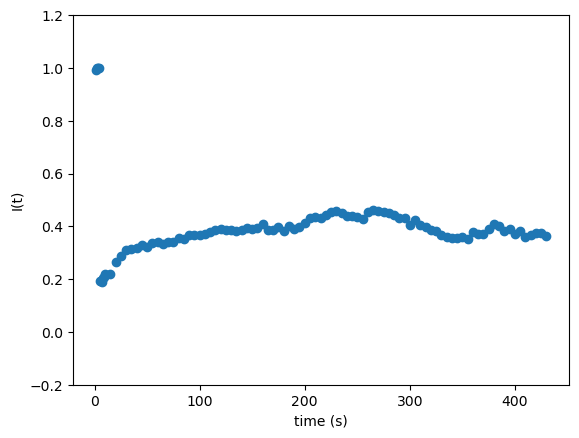

In [22]:
FRAPfrac = np.array(I_FRAP) / np.max(I_FRAP)

plt.figure()
plt.errorbar(t, FRAPfrac, fmt='o')
plt.xlabel("time (s)")
plt.ylabel("I(t)")
plt.ylim([-0.2, 1.2])
plt.show()

# Fit Data

In [24]:
if fitEnd == 0:
    fitEnd = len(FRAPfrac)

tfit = t[bleachFrame-1:fitEnd]
yfit = FRAPfrac[bleachFrame-1:fitEnd]

popt, _ = curve_fit(exp_model, tfit, yfit, p0=[0.2, 0.5, 0.005])

Iinf, I0, k = popt

fit_curve = exp_model(t, *popt)

plt.plot(t, FRAPfrac, 'o')
plt.plot(t, fit_curve, 'r-')
plt.axhline(Iinf, linestyle='--')

plt.title(f"k={k:.4f}, Iinf={Iinf:.3f}")
plt.show()

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 800.

# Save Data

In [ ]:
FULLdatatable = np.column_stack([t, I_FRAP, I_FRAPunc, I_FRAPunb])

os.makedirs("RESULTS", exist_ok=True)

np.savetxt(f"RESULTS/FRAPvars_{ROInum}.dat", FULLdatatable)

import pickle
with open(f"RESULTS/FRAPvars_{ROInum}.pkl", "wb") as f:
    pickle.dump({"data": FULLdatatable, "fit": popt}, f)